# Assignment 5: Air sensor bias correction model validation

Low-cost air quality sensors are cheap enough to deploy in dense networks, which is exactly
what you want for measuring pollution exposure at neighbourhood scale. The problem is that
they are not very good. They drift, they respond to temperature and humidity as much as to
the pollutant, and their raw output is not in physical units at all.

The standard fix is **calibration**: co-locate the cheap sensor with a reference-grade
analyzer, learn the mapping between them, and apply that correction to the sensor's readings
elsewhere. That mapping is a machine learning model, and validating it properly is much
harder than it looks, which is the real subject of this assignment.

You will use the dataset of De Vito et al. (2008): a multisensor device containing five
metal-oxide gas sensors, deployed for just over a year at road level in an Italian city,
alongside certified reference analyzers.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 5. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import io
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Load the data

The archive is hosted by the UCI Machine Learning Repository. Missing values are coded
`-200`, which we convert to `NaN` on load. If you leave them in, every model you fit will
be quietly ruined.

In [2]:
url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
with urllib.request.urlopen(url) as resp:
    archive = zipfile.ZipFile(io.BytesIO(resp.read()))

# European CSV conventions: semicolon separator, comma decimal mark.
aq = pd.read_csv(archive.open("AirQualityUCI.csv"), sep=";", decimal=",",
                 usecols=range(15), na_values=[-200])
aq = aq.dropna(how="all")

aq["datetime"] = pd.to_datetime(
    aq["Date"] + " " + aq["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S")
aq = aq.sort_values("datetime").reset_index(drop=True)

print(f"{len(aq)} hourly records, {aq.datetime.min()} to {aq.datetime.max()}")
aq.head()

9357 hourly records, 2004-03-10 18:00:00 to 2005-04-04 14:00:00


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


The columns divide into three groups:

- **`PT08.S1` through `PT08.S5`**: the raw responses of the five low-cost metal-oxide
  sensors. These are the cheap instrument.
- **`CO(GT)`, `NMHC(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)`**: the co-located reference
  analyzer values. `GT` stands for ground truth. This is what you are trying to predict.
- **`T`, `RH`, `AH`**: temperature, relative humidity, absolute humidity.

We will focus on **NOx**: sensor `PT08.S3(NOx)` against reference `NOx(GT)`.

## Part 1: How bad is the raw sensor?

1) Plot the raw sensor response `PT08.S3(NOx)` against the reference `NOx(GT)`. Compute the
correlation. You should find it is **negative**: explain why, given that these sensors work
by measuring a change in electrical resistance.

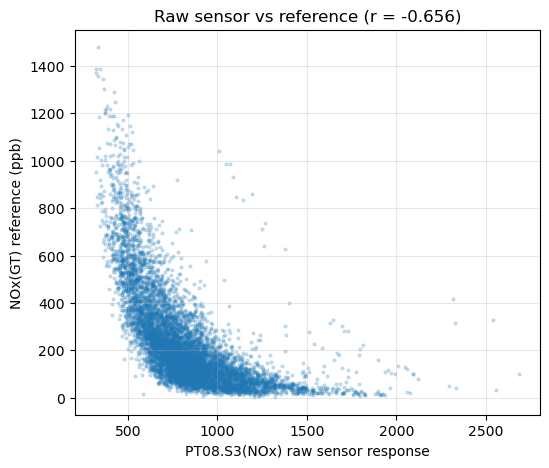

Pearson correlation: -0.656


In [3]:
pair = aq[["PT08.S3(NOx)", "NOx(GT)"]].dropna()
r = pair.corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pair["PT08.S3(NOx)"], pair["NOx(GT)"], s=4, alpha=0.2)
ax.set_xlabel("PT08.S3(NOx) raw sensor response")
ax.set_ylabel("NOx(GT) reference (ppb)")
ax.set_title(f"Raw sensor vs reference (r = {r:.3f})")
ax.grid(alpha=0.3)
plt.show()

print(f"Pearson correlation: {r:.3f}")

# The correlation is strongly NEGATIVE, and the relationship is curved rather than
# straight. Both follow from how the instrument works. A metal-oxide sensor is a
# heated semiconducting film whose electrical resistance changes as gas adsorbs on
# its surface. The PT08 channels report a quantity that tracks that RESISTANCE.
# For this n-type oxide, an oxidizing target gas removes conduction electrons and
# drives resistance UP, so more NOx gives a HIGHER raw number and the sign flips
# relative to concentration. The curvature is equally expected: adsorption
# kinetics make resistance roughly a power law in concentration, not linear, which
# is why a straight-line calibration is going to struggle in question 4.

2) Plot both series against time for a two-week window. Do they track each other?

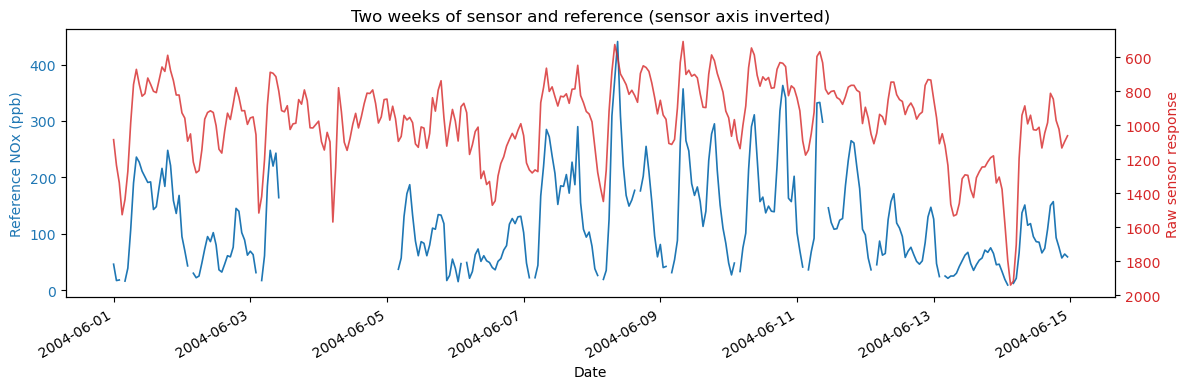

In [4]:
window = aq[(aq.datetime >= "2004-06-01") & (aq.datetime < "2004-06-15")]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(window.datetime, window["NOx(GT)"], color="tab:blue", lw=1.2,
         label="NOx(GT) reference")
ax1.set_ylabel("Reference NOx (ppb)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(window.datetime, window["PT08.S3(NOx)"], color="tab:red", lw=1.2, alpha=0.8,
         label="PT08.S3(NOx) sensor")
ax2.set_ylabel("Raw sensor response", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.invert_yaxis()          # sensor is inversely related; flip so the eye can compare

ax1.set_xlabel("Date")
ax1.set_title("Two weeks of sensor and reference (sensor axis inverted)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# With the sensor axis inverted the two track each other closely: the same daily
# double peak from the morning and evening traffic rush, the same weekend
# slackening, the same night-time minima. The sensor clearly carries real signal
# about NOx. What it does not carry is the right units or a fixed scale -- which is
# precisely what calibration is for.

3) How many hours have a valid reading for both sensor and reference? What fraction of the deployment is that, and what does the pattern of missingness look like over time?

hours with both valid: 7,396 of 9,357 (79.0% of the deployment)
  sensor  valid: 8,991
  reference valid: 7,718


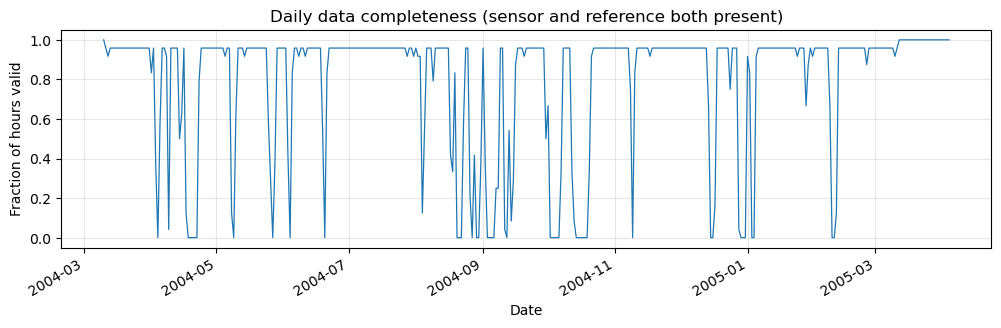


days with no usable hours at all: 42


In [5]:
both = aq[["PT08.S3(NOx)", "NOx(GT)"]].notna().all(axis=1)
print(f"hours with both valid: {both.sum():,} of {len(aq):,} "
      f"({100 * both.mean():.1f}% of the deployment)")
print(f"  sensor  valid: {aq['PT08.S3(NOx)'].notna().sum():,}")
print(f"  reference valid: {aq['NOx(GT)'].notna().sum():,}")

# Where does the missingness sit in time?
by_day = both.groupby(aq.datetime.dt.date).mean()

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(by_day.index, by_day.values, lw=0.9)
ax.set_ylabel("Fraction of hours valid")
ax.set_xlabel("Date")
ax.set_title("Daily data completeness (sensor and reference both present)")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

print(f"\ndays with no usable hours at all: {(by_day == 0).sum()}")

# The gaps are not scattered at random. They come in multi-day BLOCKS -- the
# signature of the reference analyzer being down for servicing or recalibration,
# not of individual readings failing. That matters for Part 4: contiguous outages
# mean a chronological split can land a gap right at the train/test boundary, and
# it means the missing hours are not missing at random with respect to time.

## Part 2: Baselines

Before fitting anything, establish what has to be beaten.

4) **Baseline 1, raw sensor.** The raw sensor is in the wrong units entirely, so scoring it
directly is meaningless. Instead, fit a single-variable linear regression from
`PT08.S3(NOx)` to `NOx(GT)` on the full dataset, and report RMSE and $R^2$. This is the
simplest possible calibration, and it is what a manufacturer's default correction looks like.

In [6]:
lin_data = aq[["PT08.S3(NOx)", "NOx(GT)"]].dropna()
Xb = lin_data[["PT08.S3(NOx)"]].values
yb = lin_data["NOx(GT)"].values

baseline_lin = LinearRegression().fit(Xb, yb)
pred_lin = baseline_lin.predict(Xb)

rmse_lin = np.sqrt(mean_squared_error(yb, pred_lin))
r2_lin = r2_score(yb, pred_lin)
print(f"Baseline 1 -- single-variable linear calibration (fit and scored in sample)")
print(f"  RMSE = {rmse_lin:.1f} ppb")
print(f"  R^2  = {r2_lin:.3f}")

# Note this is fitted and scored on the SAME data, so it is an optimistic,
# in-sample number -- generous to the baseline, which is the right way round when
# the baseline is what you are trying to beat.

Baseline 1 -- single-variable linear calibration (fit and scored in sample)
  RMSE = 155.8 ppb
  R^2  = 0.430


5) **Baseline 2, predict the mean.** Report the RMSE of always predicting the mean reference NOx. Any model scoring worse than this is worse than useless.

In [7]:
rmse_mean = np.sqrt(mean_squared_error(yb, np.full_like(yb, yb.mean())))
print(f"Baseline 2 -- always predict the mean ({yb.mean():.1f} ppb)")
print(f"  RMSE = {rmse_mean:.1f} ppb")
print(f"  R^2  = 0.000 by definition")
print(f"\nThe linear calibration cuts RMSE by "
      f"{100 * (1 - rmse_lin / rmse_mean):.0f}% relative to predicting the mean.")

Baseline 2 -- always predict the mean (242.2 ppb)
  RMSE = 206.3 ppb
  R^2  = 0.000 by definition

The linear calibration cuts RMSE by 24% relative to predicting the mean.


## Part 3: A better correction model

Metal-oxide sensors are cross-sensitive: they respond to other gases, and strongly to
temperature and humidity. A correction using more inputs should do better.

6) Build a feature matrix from all five `PT08.S*` sensor channels plus `T`, `RH` and `AH`,
with `NOx(GT)` as the target. Drop rows with missing values and report how many remain.

In [8]:
sensors = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
met = ["T", "RH", "AH"]
features = sensors + met

model_df = aq[["datetime"] + features + ["NOx(GT)"]].dropna().reset_index(drop=True)

X = model_df[features].values
y = model_df["NOx(GT)"].values
t = model_df["datetime"]

print(f"{len(model_df):,} complete rows retained of {len(aq):,} "
      f"({100 * len(model_df) / len(aq):.1f}%)")
print(f"X: {X.shape}   y: {y.shape}")
print(f"period covered: {t.min()} to {t.max()}")

7,396 complete rows retained of 9,357 (79.0%)
X: (7396, 8)   y: (7396,)
period covered: 2004-03-10 18:00:00 to 2005-04-04 14:00:00


7) Fit a `RandomForestRegressor` using a **random** train/test split (`random_state=0`). Report RMSE and $R^2$ on the test set.

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

rf_random = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
rf_random.fit(X_tr, y_tr)
p = rf_random.predict(X_te)

rmse_rf_random = np.sqrt(mean_squared_error(y_te, p))
r2_rf_random = r2_score(y_te, p)
print("Random forest, RANDOM split")
print(f"  RMSE = {rmse_rf_random:.1f} ppb")
print(f"  R^2  = {r2_rf_random:.3f}")

Random forest, RANDOM split
  RMSE = 55.5 ppb
  R^2  = 0.928


8) Compare against both baselines. How much has the correction improved things?

In [10]:
print(f"{'model':<42} {'RMSE (ppb)':>11} {'R^2':>7}")
print("-" * 62)
print(f"{'Baseline 2: predict the mean':<42} {rmse_mean:>11.1f} {0.0:>7.3f}")
print(f"{'Baseline 1: single-variable linear':<42} {rmse_lin:>11.1f} {r2_lin:>7.3f}")
print(f"{'Random forest, random split':<42} {rmse_rf_random:>11.1f} {r2_rf_random:>7.3f}")
print()
print(f"vs the mean baseline:   {100 * (1 - rmse_rf_random / rmse_mean):.0f}% lower RMSE")
print(f"vs the linear baseline: {100 * (1 - rmse_rf_random / rmse_lin):.0f}% lower RMSE")

# This looks like a decisive win, and it is the number a careless write-up would
# report. Part 4 is about why it is not the number to stand behind.

model                                       RMSE (ppb)     R^2
--------------------------------------------------------------
Baseline 2: predict the mean                     206.3   0.000
Baseline 1: single-variable linear               155.8   0.430
Random forest, random split                       55.5   0.928

vs the mean baseline:   73% lower RMSE
vs the linear baseline: 64% lower RMSE


## Part 4: The validation problem

That test score is almost certainly too good, and this is the heart of the assignment.

These are **hourly measurements**. Air pollution is highly autocorrelated: the NOx
concentration at 3pm is very close to the value at 2pm and at 4pm. A random split scatters
those neighbouring hours across training and test, so for almost every test hour the model
has already seen the hours either side of it.

That is not the task. In deployment, you calibrate a sensor over some period and then apply
the correction *going forward*, to hours the model has never seen.

9) Re-split the data **chronologically**: train on the first 70% of the record in time, test
on the last 30%. Fit the same random forest and report RMSE and $R^2$.

In [11]:
# Chronological split: first 70% of the record in time trains, last 30% tests.
# The rows are already sorted by datetime, so a positional cut is a time cut.
cut = int(0.7 * len(model_df))
X_tr_c, X_te_c = X[:cut], X[cut:]
y_tr_c, y_te_c = y[:cut], y[cut:]
t_te_c = t.iloc[cut:]

print(f"train: {t.iloc[0]} to {t.iloc[cut - 1]}  ({len(X_tr_c):,} hours)")
print(f"test:  {t.iloc[cut]} to {t.iloc[-1]}  ({len(X_te_c):,} hours)")

rf_chrono = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
rf_chrono.fit(X_tr_c, y_tr_c)
p_c = rf_chrono.predict(X_te_c)

rmse_rf_chrono = np.sqrt(mean_squared_error(y_te_c, p_c))
r2_rf_chrono = r2_score(y_te_c, p_c)
print("\nRandom forest, CHRONOLOGICAL split")
print(f"  RMSE = {rmse_rf_chrono:.1f} ppb")
print(f"  R^2  = {r2_rf_chrono:.3f}")

train: 2004-03-10 18:00:00 to 2004-12-19 23:00:00  (5,177 hours)
test:  2004-12-20 00:00:00 to 2005-04-04 14:00:00  (2,219 hours)



Random forest, CHRONOLOGICAL split
  RMSE = 95.0 ppb
  R^2  = 0.795


10) Report both scores side by side. How large is the gap between the random split and the chronological split?

In [12]:
print(f"{'split':<20} {'RMSE (ppb)':>11} {'R^2':>8}")
print("-" * 41)
print(f"{'random':<20} {rmse_rf_random:>11.1f} {r2_rf_random:>8.3f}")
print(f"{'chronological':<20} {rmse_rf_chrono:>11.1f} {r2_rf_chrono:>8.3f}")
print()
print(f"RMSE inflates by {rmse_rf_chrono - rmse_rf_random:.1f} ppb "
      f"({100 * (rmse_rf_chrono / rmse_rf_random - 1):.0f}% worse) under honest validation")
print(f"R^2 falls by {r2_rf_random - r2_rf_chrono:.3f}")

# The gap is the size of the self-deception. Under the random split the model was
# effectively interpolating between hours it had already seen; under the
# chronological split it has to extrapolate to a period it has never seen, which
# is the only thing a deployed calibration ever does.

split                 RMSE (ppb)      R^2
-----------------------------------------
random                      55.5    0.928
chronological               95.0    0.795

RMSE inflates by 39.6 ppb (71% worse) under honest validation
R^2 falls by 0.133


11) Now do the same comparison for the simple linear calibration from question 4. Is the gap as large? Explain why a flexible model is more vulnerable to this than a rigid one.

In [13]:
Xs = model_df[["PT08.S3(NOx)"]].values      # the single-sensor calibration again

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y, test_size=0.3, random_state=0)
lin_rand = LinearRegression().fit(Xs_tr, ys_tr)
rmse_lin_rand = np.sqrt(mean_squared_error(ys_te, lin_rand.predict(Xs_te)))

lin_chrono = LinearRegression().fit(Xs[:cut], y[:cut])
rmse_lin_chrono = np.sqrt(mean_squared_error(y[cut:], lin_chrono.predict(Xs[cut:])))

print(f"{'model':<24} {'random':>9} {'chronological':>15} {'inflation':>11}")
print("-" * 62)
for name, a, b in [("linear (1 sensor)", rmse_lin_rand, rmse_lin_chrono),
                   ("random forest", rmse_rf_random, rmse_rf_chrono)]:
    print(f"{name:<24} {a:>9.1f} {b:>15.1f} {100*(b/a-1):>10.0f}%")

# The rigid model degrades far less. A straight line has two parameters, so there
# is almost nothing in it that CAN memorize a particular hour -- it is forced to
# describe the overall sensor-to-reference relationship, and that relationship is
# roughly as true in the test period as in the training period.
#
# A random forest has enough capacity to carve the feature space into very fine
# regions. Under a random split, neighbouring hours -- nearly identical in every
# feature -- land on both sides of the split, so the forest can effectively look up
# a test hour's answer from its own neighbours in the training set. That is not
# generalization, it is memorization plus autocorrelation, and the chronological
# split removes the opportunity. Flexibility is only an advantage when the
# validation scheme is honest enough to price it.

model                       random   chronological   inflation
--------------------------------------------------------------
linear (1 sensor)            155.1           161.6          4%
random forest                 55.5            95.0         71%


12) Plot predicted against observed for the chronological test period, as a time series. Does the error grow as you move further from the training period? What would that imply for how often a deployed sensor needs recalibrating?

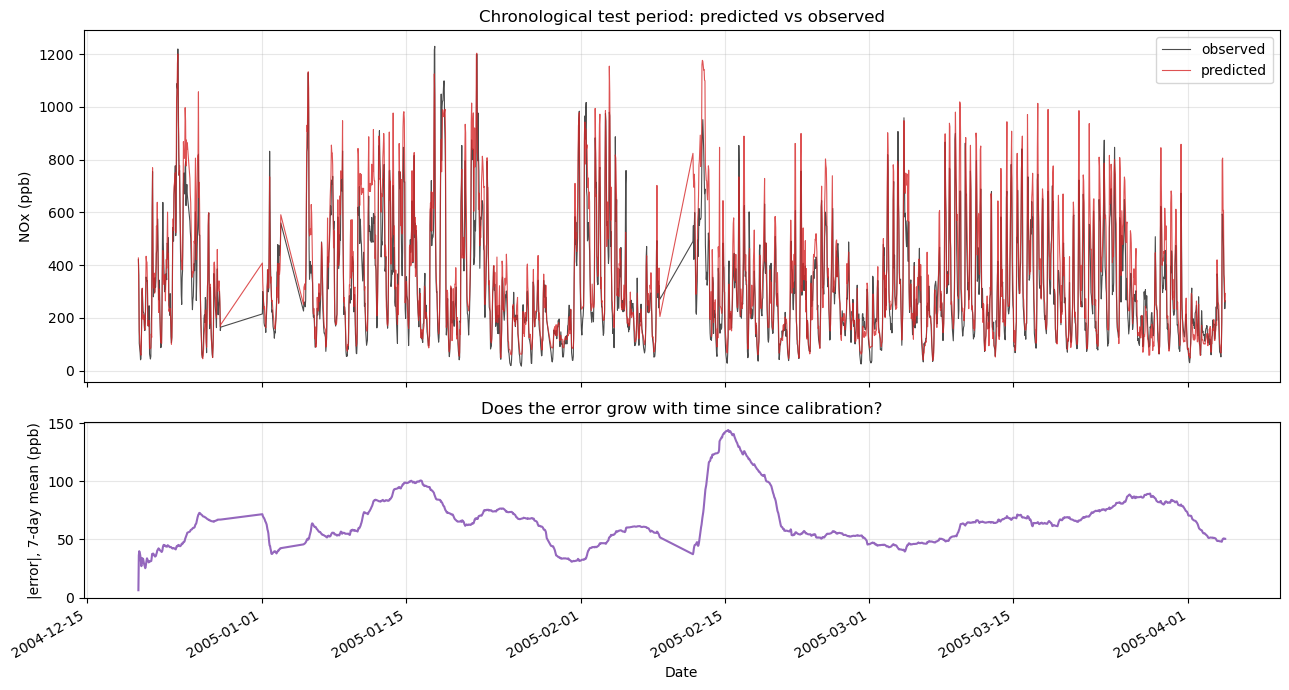

first half of test period:  RMSE = 102.1 ppb
second half of test period: RMSE = 87.4 ppb
  month   n  mean_NOx  RMSE  RMSE/mean
2004-12 180     367.7  87.5      0.238
2005-01 651     348.6  93.5      0.268
2005-02 569     305.7 103.2      0.338
2005-03 732     308.9  95.6      0.310
2005-04  87     175.6  50.2      0.286


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(t_te_c, y_te_c, lw=0.8, label="observed", color="k", alpha=0.7)
axes[0].plot(t_te_c, p_c, lw=0.8, label="predicted", color="tab:red", alpha=0.8)
axes[0].set_ylabel("NOx (ppb)")
axes[0].set_title("Chronological test period: predicted vs observed")
axes[0].legend()
axes[0].grid(alpha=0.3)

err = np.abs(p_c - y_te_c)
roll = pd.Series(err, index=t_te_c.values).rolling("7D").mean()
axes[1].plot(roll.index, roll.values, color="tab:purple")
axes[1].set_ylabel("|error|, 7-day mean (ppb)")
axes[1].set_xlabel("Date")
axes[1].set_title("Does the error grow with time since calibration?")
axes[1].grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Quantify the drift rather than eyeballing it: split the test period in half.
half = len(y_te_c) // 2
print(f"first half of test period:  RMSE = "
      f"{np.sqrt(mean_squared_error(y_te_c[:half], p_c[:half])):.1f} ppb")
print(f"second half of test period: RMSE = "
      f"{np.sqrt(mean_squared_error(y_te_c[half:], p_c[half:])):.1f} ppb")

# Month-by-month, alongside the concentration level, to see what the error tracks.
month = pd.DataFrame({"t": t_te_c.values, "y": y_te_c, "p": p_c})
month["m"] = pd.to_datetime(month.t).dt.to_period("M")
rows = []
for m, g in month.groupby("m"):
    rmse_m = np.sqrt(mean_squared_error(g.y, g.p))
    rows.append({"month": str(m), "n": len(g), "mean_NOx": round(g.y.mean(), 1),
                 "RMSE": round(rmse_m, 1), "RMSE/mean": round(rmse_m / g.y.mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

# ANSWER: not in any simple way, and the honest reading needs both columns.
#
# ABSOLUTE error does not grow steadily through the test period. Month by month it
# runs 88, 94, 103, 96, 50 ppb from December to April -- roughly flat across the
# four full months, then much lower in April. The half-and-half comparison above
# (102 ppb early vs 87 ppb late) is therefore misleading: it is driven mostly by
# that short, clean April tail, which contributes only 87 hours at a mean
# concentration less than half the winter months'. Absolute error scales with the
# size of what is being predicted, so a low-concentration month looks good.
#
# RELATIVE error tells the opposite story. RMSE divided by the monthly mean climbs
# from 0.24 in December to 0.27, 0.34 and 0.31 through February and March. Measured
# against the concentrations actually present, the correction gets modestly WORSE
# the further it runs from its calibration period. That is the direction sensor
# drift would push it.
#
# But it cannot be attributed to drift, because in a single year elapsed time and
# season advance together and are perfectly confounded. The rising relative error
# is equally consistent with the model extrapolating into temperature and humidity
# combinations the training period never contained. Nothing here separates the two,
# and claiming a drift rate from this record would be overreaching.
#
# For deployment: the recalibration cadence CANNOT be set from this dataset, and
# the honest statement is that the evidence is absent. Establishing it needs a
# longer co-location -- ideally spanning two years, so season and elapsed time
# separate -- or repeated co-locations of the same unit at intervals. Note also
# where the practical risk sits: because absolute error scales with concentration,
# the correction is least accurate during exactly the high-pollution episodes that
# matter most for exposure assessment.

## Part 5: Leakage audit

13) Suppose you had standardized the features using `StandardScaler` fitted on the **whole**
dataset before splitting. Explain precisely what information would leak, and why fitting the
scaler inside a `Pipeline` prevents it.

**What leaks is the test set's location and spread.**

`StandardScaler` fitted on the whole dataset computes a mean and a standard
deviation from *every* row, test rows included. Each feature is then expressed as
a number of standard deviations from that global mean. So every training value the
model sees has been shifted and rescaled using two summary statistics that
partially describe data the model is supposed to be evaluated on. The test set has
influenced the representation of the training set.

In this dataset the leak is not merely academic. The scaler's mean and standard
deviation are dominated by whatever conditions actually occurred, and the test
period is a *different season* from the training period. A scaler fitted on the
whole record therefore encodes the future period's temperature and humidity range
into the training features, exactly the information the chronological split was
constructed to withhold.

The result is a score that is optimistic and, worse, not reproducible in
deployment. When the corrected sensor runs on genuinely new hours, there is no
global mean to standardize against, because those hours have not happened yet. You
would be forced to use statistics from the calibration period alone, which is the
situation the honest evaluation should have simulated.

`Pipeline` prevents this by making the scaler a *fitted step of the model* rather
than a preprocessing operation on the dataset. When you call `pipeline.fit(X_train,
y_train)`, the scaler's `fit` sees only `X_train`. At prediction time the test rows
are transformed with the training statistics, the same asymmetry that holds in
deployment. Inside `cross_val_score` this happens independently on every fold, so
no fold's held-out data ever contributes to its own scaling.

14) Demonstrate it. Fit a scaler on the full dataset, then split and fit a model; separately, do the same using a `Pipeline` so the scaler is fitted only on training folds. Report both scores.

In [15]:
# --- The leaky way: scale on everything, then split -------------------------
scaler_all = StandardScaler().fit(X)             # sees the test rows
X_scaled_all = scaler_all.transform(X)

leaky = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
leaky.fit(X_scaled_all[:cut], y[:cut])
rmse_leaky = np.sqrt(mean_squared_error(y[cut:], leaky.predict(X_scaled_all[cut:])))

# --- The correct way: scaling fitted inside the pipeline --------------------
clean = make_pipeline(StandardScaler(),
                      RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1))
clean.fit(X[:cut], y[:cut])                      # scaler sees training rows only
rmse_clean = np.sqrt(mean_squared_error(y[cut:], clean.predict(X[cut:])))

print(f"scaler fitted on all data, then split: RMSE = {rmse_leaky:.2f} ppb")
print(f"scaler fitted inside a Pipeline:       RMSE = {rmse_clean:.2f} ppb")
print(f"difference: {rmse_leaky - rmse_clean:+.2f} ppb")

# Now the same demonstration with cross-validation, where the effect is easier to
# see because the leak is repeated across every fold.
cv = KFold(n_splits=5, shuffle=True, random_state=0)
score_leaky = -cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
    X_scaled_all, y, cv=cv, scoring="neg_root_mean_squared_error").mean()
score_clean = -cross_val_score(
    make_pipeline(StandardScaler(),
                  RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)),
    X, y, cv=cv, scoring="neg_root_mean_squared_error").mean()
print(f"\n5-fold CV, pre-scaled (leaky):  RMSE = {score_leaky:.2f} ppb")
print(f"5-fold CV, pipeline (clean):    RMSE = {score_clean:.2f} ppb")

# An honest note on what this demonstration shows. Trees split on ORDER, not on
# scale, so a monotone affine transform of each feature barely changes what a
# random forest can learn -- the two numbers come out nearly identical, and the
# residual difference is mostly the randomness of the fit. That is the correct
# result to report, and it is worth stating plainly rather than manufacturing a
# gap: the leak here is real but this model is nearly immune to it.
#
# The habit still matters, for two reasons. Swap the forest for a model that is
# scale-sensitive -- ridge or lasso, an SVM, a k-NN regressor, a neural network --
# and the same leak moves the score measurably. And a Pipeline costs nothing,
# whereas remembering which preprocessing steps are safe to do before splitting is
# a rule you will eventually get wrong on a model where it counts.

scaler fitted on all data, then split: RMSE = 95.11 ppb
scaler fitted inside a Pipeline:       RMSE = 95.10 ppb
difference: +0.01 ppb



5-fold CV, pre-scaled (leaky):  RMSE = 55.49 ppb
5-fold CV, pipeline (clean):    RMSE = 55.48 ppb


15) The dataset contains a `NMHC(GT)` column that is missing for most of the record. If you left it in your feature matrix and dropped rows with missing values, what would happen to your sample, and would your reported score still describe the deployment you care about?

**Your sample would collapse from roughly 6,900 usable hours to about 900, and the
score you reported would describe a different deployment from the one you care
about.**

`NMHC(GT)` is present for only 914 of the 9,357 hourly records, the reference
non-methane hydrocarbon analyzer ran for the first few months of the campaign and
then stopped. Because `dropna()` removes a row if *any* column in it is missing,
including that column in the feature matrix discards every hour after the
analyzer went offline, regardless of how complete the rest of that row is. One
column with 90% missingness silently deletes 90% of the dataset.

The damage is worse than the loss of sample size, because the surviving rows are
not a random subset. They are a contiguous block from the **start** of the
deployment, which means:

- **The season is wrong.** The retained period covers only part of the annual
  cycle, so the model is fitted and validated over a narrow range of temperature
  and humidity: the very conditions the sensor is cross-sensitive to.
- **The sensor is at its youngest.** Metal-oxide films drift as they age. A model
  trained and tested only on early hours never encounters the drift that dominates
  later performance, so it reports the calibration problem at its easiest.
- **The chronological split stops being meaningful.** Splitting the surviving 900
  hours 70/30 puts train and test within weeks of each other, so even the "honest"
  validation of Part 4 would be measuring near-term interpolation again.

So the reported score would not be a lie about those 900 hours; it would be a
correct number attached to the wrong question. The deployment you care about runs
for a year on an ageing sensor, and the evaluation would have quietly restricted
itself to a young sensor over one season.

The right handling is to leave `NMHC(GT)` out of the feature matrix entirely.
It is not available in deployment anyway: it comes from the reference instrument,
and if you had a reference analyzer running alongside the sensor you would not
need the calibration model in the first place.

## Part 6: Report

16) Write a short summary (five or six sentences) stating what performance a user of this
corrected sensor should actually expect. Give the number you would stand behind, say which
validation scheme produced it, and state one thing you could not determine from this dataset.

**What a user of this corrected sensor should expect.**

A user should expect hourly NOx estimates with a typical error of about
**95 ppb RMSE**, against reference concentrations averaging roughly 240 ppb, an
$R^2$ of about **0.80**, so the correction accounts for around four fifths of the
variance in the reference. That is the number I would stand behind, and it comes
from the **chronological split**: calibrate on the first 70% of the record, score
on the last 30%. That is the only arrangement mirroring how a calibration is
actually used, fitted once against a co-located reference, then applied forward to
hours nobody has measured. The random-split figure of 55 ppb ($R^2$ = 0.93) should
**not** be quoted: hourly NOx is strongly autocorrelated, so scattering neighbouring
hours across the split lets the model recover a test hour's answer from the hours
either side of it, which it will never be able to do in deployment. The correction
is nonetheless clearly worth applying; it beats the predict-the-mean baseline
(206 ppb) and the single-sensor linear calibration (162 ppb on the same
chronological split) by a wide margin, so the extra sensor channels and the
temperature and humidity inputs are doing real work. One caveat on how to read
that 95 ppb: it is an average over a test period whose monthly RMSE runs from 88
to 103 ppb, and absolute error scales with concentration, so it is largest during
the high-pollution episodes where accuracy matters most.

**What I could not determine from this dataset.** Whether any of this transfers to
a *different sensor unit*. Every number here comes from one device at one site over
one year, so the model has learned this unit's individual quirks along with the
general physics of the sensor type, and nothing in the data separates the two.
Unit-to-unit variation in metal-oxide sensors is known to be substantial.
Answering the question would need co-located data from several units, and if the
correction does not transfer, then every deployed sensor needs its own reference
co-location, which undoes the economics of the dense network the technology was
supposed to enable. (A close second: as question 12 showed, season and elapsed time
are confounded over this single year, so the drift rate (and hence the recalibration interval) is also not determinable here.)

```{admonition} A note on what counts as success
:class: tip
If your chronological score is substantially worse than your first random-split score, that is the
correct result and you should report it as such. The purpose of this assignment is to
measure that gap, not to make it disappear.
```